In [1]:
%cd ..


/home/jovyan/project/film-recommendation


INFO:src.data_processing.data_loader:Loading MovieLens dataset...
INFO:src.data_processing.data_loader:Loading existing data from cache: data/processed/movie_metadata.parquet
INFO:src.data_processing.data_loader:Found 1180 missing movies with valid TMDB IDs. Fetching...
INFO:src.data_processing.data_loader:DOWNLOAD SUMMARY: Requested: 1180 | Saved: 0 | Failed: 1180


Movies: 82033
Ratings: 33832162
Users: 330975


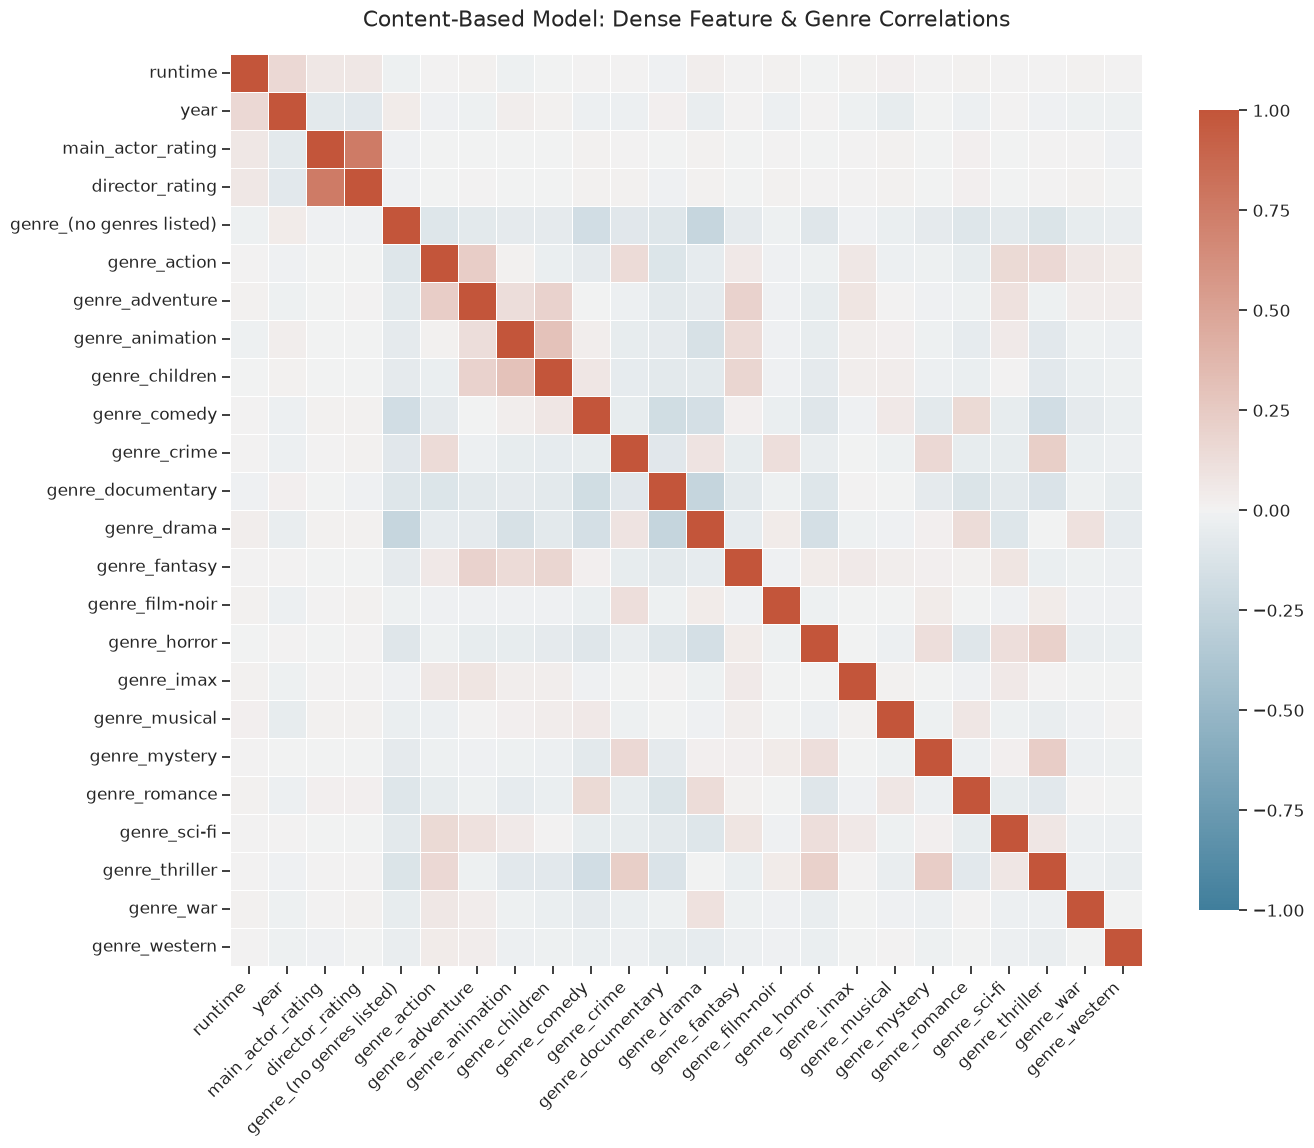

,movieId,title,year,cast,main_actor,director,rating,runtime,keywords,vote_count,...,genre_film-noir,genre_horror,genre_imax,genre_musical,genre_mystery,genre_romance,genre_sci-fi,genre_thriller,genre_war,genre_western
0,1.0,Toy Story,1995,"[Tom Hanks, Tim Allen, Don Rickles, Jim Varney...",Tom Hanks,John Lasseter,7.978,81.0,"[rescue, friendship, mission, jealousy, villai...",20023.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,4.0,Waiting to Exhale,1995,"[Whitney Houston, Angela Bassett, Loretta Devi...",Whitney Houston,Forest Whitaker,6.243,127.0,"[based on novel or book, single mother, divorc...",206.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,5.0,Father of the Bride Part II,1995,"[Steve Martin, Diane Keaton, Martin Short, Kim...",Steve Martin,Charles Shyer,6.273,106.0,"[daughter, baby, parent child relationship, mi...",812.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
3,6.0,Heat,1995,"[Al Pacino, Robert De Niro, Val Kilmer, Jon Vo...",Al Pacino,Michael Mann,7.937,170.0,"[robbery, chase, obsession, detective, heist, ...",8403.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
4,7.0,Sabrina,1995,"[Harrison Ford, Julia Ormond, Greg Kinnear, Na...",Harrison Ford,Sydney Pollack,6.210,127.0,"[chauffeur, sibling relationship, paris, franc...",696.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5,8.0,Tom and Huck,1995,"[Jonathan Taylor Thomas, Brad Renfro, Eric Sch...",Jonathan Taylor Thomas,Peter Hewitt,5.300,97.0,"[based on novel or book, mississippi river, ma...",214.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
6,9.0,Sudden Death,1995,"[Jean-Claude Van Damme, Powers Boothe, Raymond...",Jean-Claude Van Damme,Peter Hyams,6.034,111.0,"[explosive, hostage, ice hockey, terrorism, vi...",812.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
7,10.0,GoldenEye,1995,"[Pierce Brosnan, Sean Bean, Izabella Scorupco,...",Pierce Brosnan,Martin Campbell,6.903,130.0,"[computer virus, cuba, falsely accused, secret...",4353.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
8,11.0,The American President,1995,"[Michael Douglas, Annette Bening, Martin Sheen...",Michael Douglas,Rob Reiner,6.539,113.0,"[new love, usa president, the white house, hol...",785.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
9,12.0,Dracula: Dead and Loving It,1995,"[Leslie Nielsen, Mel Brooks, Amy Yasbeck, Pete...",Leslie Nielsen,Mel Brooks,6.071,88.0,"[vampire, satire, spoof, dracula]",1113.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


In [2]:
from src.features.movie_features import plot_content_model_correlations
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from src.data_processing.data_loader import MovieLensDataLoader
from src.models.content_based import ContentBasedRecommender, ContentBasedConfig
from src.models.collaborative_filtering import CollaborativeFiltering
from src.models.hybrid import HybridRecommender
from src.models.cascading_hybrid import CascadingHybridRecommender
from src.models.popular_baseline_model import PopularityBaseline
from src.evaluation.evaluator import RecommendationEvaluator
from src.evaluation.visualisation import RecommendationVisualizer
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_context('notebook', font_scale=1.1)

# --- How to use it ---
config = ContentBasedConfig(
    main_actor_weight=0.3,
    director_weight=0.3,
    cast_weight=0.3,
    keywords_weight=0.6,
    numerical_weight=0.1,
    similarity_threshold=0.15,
    top_k_default=20
)
loader = MovieLensDataLoader("ml-latest")
data_dict = loader.load_data()
await loader.letterboxd_data_async(max_concurrent_requests=100)

movies_df = pd.DataFrame(loader.movie_data)

ratings_df = data_dict['ratings']
genre_features = loader.preprocess_movies()
movies_df = pd.concat([movies_df, genre_features], axis=1)
movies_df = movies_df.dropna().reset_index(drop=True)

print(f"Movies: {len(movies_df)}")
print(f"Ratings: {len(ratings_df)}")
print(f"Users: {ratings_df['userId'].nunique()}")
recommender = ContentBasedRecommender(config)
plot_content_model_correlations(recommender, movies_df)
movies_df.head(10)